In [19]:
import os
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"

import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# class FrequencyEncoder:
#     def __init__(self, res=512, pitch=3.6e-6, wavelength=638e-9):
#         self.res = res
#         self.pitch = pitch
#         self.wavelength = wavelength
        
#         #Create the Spatial Frequency Grid
#         f = torch.fft.fftfreq(res, d =pitch)
#         self.fy, self.fx = torch.meshgrid(f, f, indexing='ij')

#         #Pre-calculate the ASM Prop kernel base
#         term = (1.0 / self.wavelength)**2 - self.fx**2 - self.fy**2
#         self.phase_kernel_base = 2 * np.pi * torch.sqrt(torch.clamp(term, min=0.0))

#     def encode(self, img_path, depth_path):
#         rgb = torch.from_numpy(iio.imread(img_path).astype(np.float32)).permute(2, 0, 1)
#         depth = torch.from_numpy(iio.imread(depth_path).astype(np.float32)).squeeze()

#         #Normalize Z
#         z_max = 20.3336e-3
#         z_map = depth * z_max

#         #Encoding logic
#         encoding_arg = self.phase_kernel_base * z_map
#         freq_feat_cos = torch.cos(encoding_arg)
#         freq_feat_sin = torch.sin(encoding_arg)

#         #Final feature stack
#         engineered_input = torch.cat([
#             rgb, 
#             depth.unsqueeze(0),
#             freq_feat_cos.unsqueeze(0),
#             freq_feat_sin.unsqueeze(0)
#         ], dim=0)

#         return engineered_input


In [21]:
def show(img, title="", cmap=None, vmin=None, vmax=None):
    plt.figure(figsize=(4,4))
    plt.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.title(title)
    plt.axis("off")
    plt.show()

In [20]:

class KOREATECH_CGH_Encoder:
    def __init__(self, res=512, pitch=3.6e-6, wavelength=638e-9):
        self.res = res
        self.pitch = pitch          # 3.6 μm pixel pitch
        self.wavelength = wavelength  # 638 nm wavelength (Red)
        
        # 1. Create the Spatial Frequency Grid (fx, fy)
        # This grid defines the diffraction angles for light propagation
        f = torch.fft.fftfreq(res, d=pitch)
        self.fy, self.fx = torch.meshgrid(f, f, indexing='ij')
        
        # 2. Pre-calculate the ASM Propagation Kernel Base
        # Defined as sqrt(1/λ² - fx² - fy²)
        term = (1.0 / self.wavelength)**2 - self.fx**2 - self.fy**2
        self.phase_kernel_base = 2 * np.pi * torch.sqrt(torch.clamp(term, min=0))

    def load_exr(self, path):
        # cv2.IMREAD_UNCHANGED is critical to preserve 32-bit float precision
        img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
        if img is None:
            raise FileNotFoundError(f"Check your path: {path}")
        return img.astype(np.float32)

    def encode(self, img_path, depth_path):
        # Load raw data
        # OpenCV loads images as BGR by default, so we convert to RGB
        bgr_img = self.load_exr(img_path)
        rgb_raw = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
        depth_raw = self.load_exr(depth_path)

        # Convert to Tensors
        rgb = torch.from_numpy(rgb_raw).permute(2, 0, 1) # [3, 512, 512]
        depth = torch.from_numpy(depth_raw).squeeze()    # [512, 512]
        
        # 3. Depth Normalization: Max depth for 512 res is 20.3336 mm
        z_max = 20.3336e-3 
        z_map = depth * z_max
        
        # 4. Frequency Encoding (Cos/Sin)
        # These features teach the model the diffraction rules for each depth
        encoding_arg = self.phase_kernel_base * z_map
        freq_cos = torch.cos(encoding_arg).unsqueeze(0)
        freq_sin = torch.sin(encoding_arg).unsqueeze(0)
        
        # 5. Depth Buckets (8 Layers)
        # Slicing the 20.33mm space into 8 discrete amplitude layers
        buckets = []
        for i in range(8):
            mask = ((depth >= i/8.0) & (depth < (i+1)/8.0)).float()
            buckets.append(rgb * mask.unsqueeze(0))
            
        # Final Stack: RGB(3) + Depth(1) + Cos(1) + Sin(1) + Buckets(24) = 30 Channels
        feature_stack = torch.cat([
            rgb, 
            depth.unsqueeze(0), 
            freq_cos, 
            freq_sin, 
            *buckets
        ], dim=0)
        
        return feature_stack


In [18]:
data_root = r"C:\Users\Kai Kumano\workspace\CGH-depth\dataset\KOREATECH-CGH-512-3.6Mu"
img_file = os.path.join(data_root, "train", "img", "0.exr")
depth_file = os.path.join(data_root, "train", "depth", "0.exr")

encoder = KOREATECH_CGH_Encoder()
feature_stack = encoder.encode(img_file, depth_file)
print(f"Engineered Input Shape: {feature_stack.shape}")

Engineered Input Shape: torch.Size([30, 512, 512])


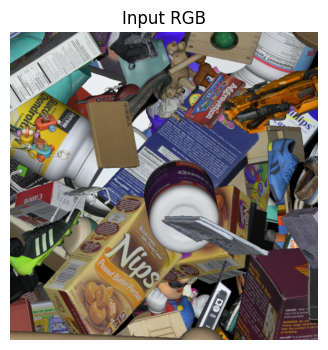

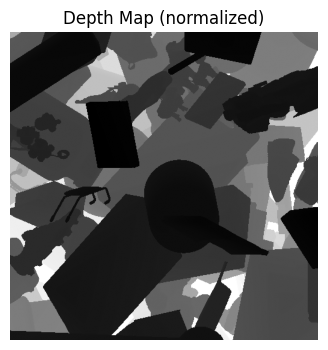

In [26]:
rgb = feature_stack[0:3].permute(1,2,0).numpy()
rgb = np.clip(rgb / rgb.max(), 0, 1)

show(rgb, "Input RGB")
depth = feature_stack[3].numpy()

show(depth, "Depth Map (normalized)", cmap="gray")



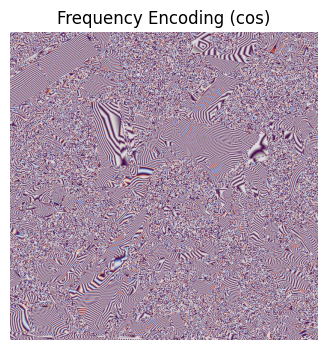

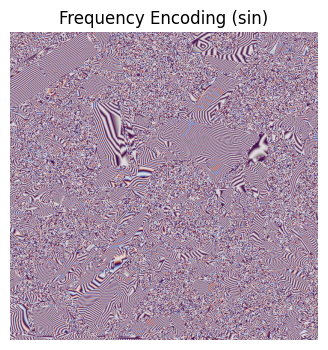

In [27]:
freq_cos = feature_stack[4].numpy()
freq_sin = feature_stack[5].numpy()

show(freq_cos, "Frequency Encoding (cos)", cmap="twilight", vmin=-1, vmax=1)
show(freq_sin, "Frequency Encoding (sin)", cmap="twilight", vmin=-1, vmax=1)


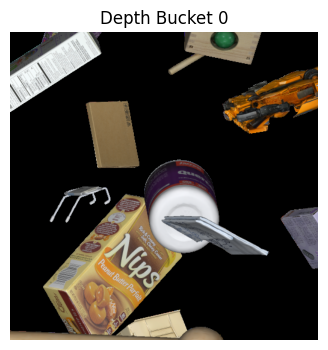

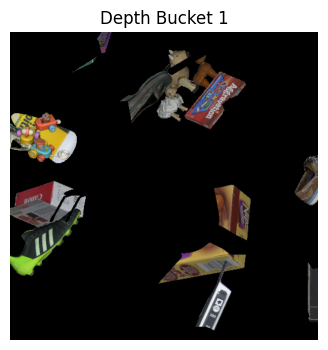

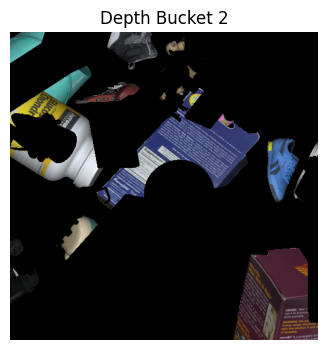

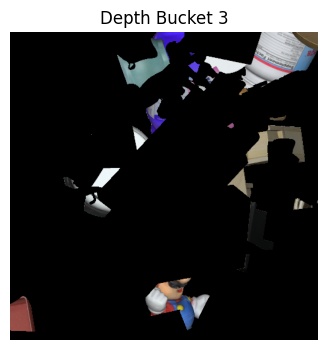

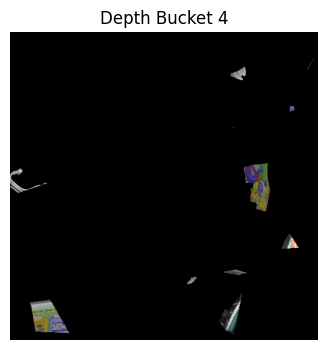

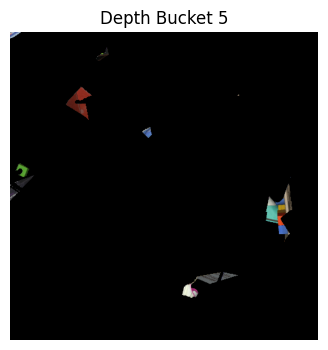

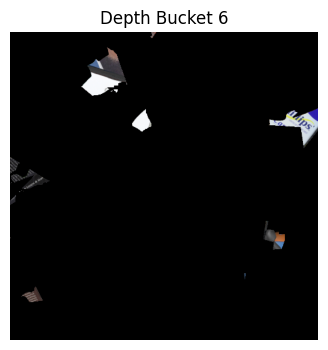

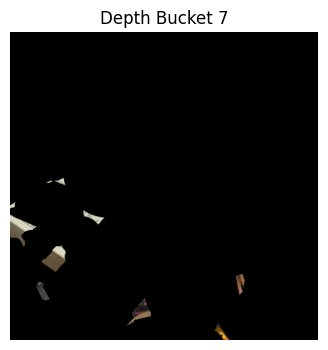

In [28]:
for i in range(8):
    bucket = feature_stack[6 + 3*i : 6 + 3*(i+1)]
    img = bucket.permute(1,2,0).numpy()
    img = np.clip(img / (img.max() + 1e-6), 0, 1)
    show(img, f"Depth Bucket {i}")
